# TP1 - Découverte et Valeurs Manquantes Simples

**Difficulté:** Débutant  
**Dataset:** ecommerce_simple.csv  
**Description:** Introduction au nettoyage avec gestion basique des valeurs manquantes

---


## Imports des Bibliothèques


In [136]:
!pip install pandas
!pip install seaborn
!pip install numpy
!pip install matplotlib
!pip install missingno

In [137]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")


 Bibliothèques importées avec succès!


## Import du Dataset


In [138]:
# Charger le dataset
df = pd.read_csv(r'C:\Users\Utilisateur\Desktop\e-commerce\Pipeline-ETL---Ingestion-transformation-et-chargement-de-donn-es-multi-sources\data\ecommerce_simple.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()


📏 Dimensions: 500 lignes × 8 colonnes
 Taille mémoire: 0.05 MB




,order_id,customer_id,product,price,quantity,category,order_date,shipping_address
0,1,8270,Laptop,1463.85,2,Accessories,2023-01-01 00:00:00,NaN
1,2,1860,Phone,761.59,3,Electronics,2023-01-01 01:00:00,"4 Main St, City"
2,3,6390,Phone,1098.20,4,Electronics,2023-01-01 02:00:00,NaN
3,4,6191,Headphones,1240.25,4,Accessories,2023-01-01 03:00:00,NaN
4,5,6734,Laptop,1091.76,3,Electronics,2023-01-01 04:00:00,NaN




<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   product           500 non-null    str    
 3   price             455 non-null    float64
 4   quantity          500 non-null    int64  
 5   category          500 non-null    str    
 6   order_date        500 non-null    str    
 7   shipping_address  234 non-null    str    
dtypes: float64(1), int64(3), str(4)
memory usage: 53.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

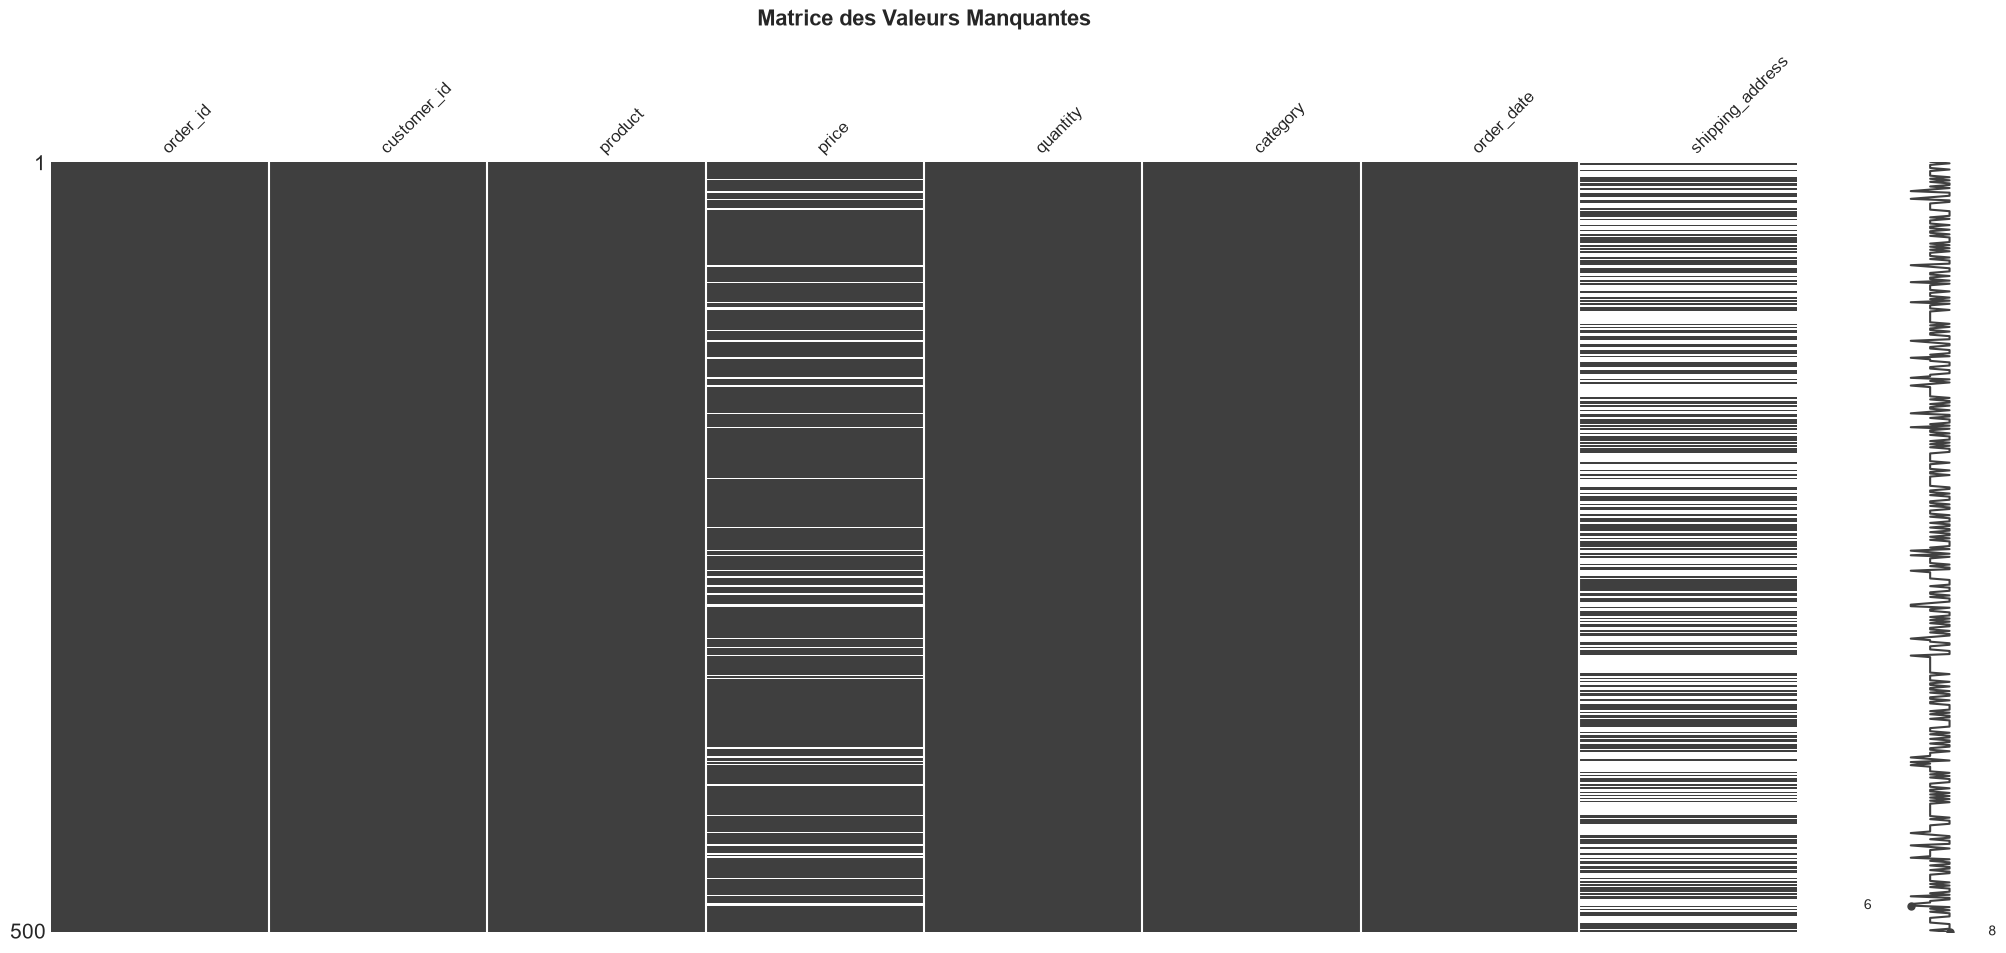


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing
shipping_address,266,53.20
price,45,9.00


In [139]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])



## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Combien de lignes et colonnes contient le dataset ?
2. Quelles colonnes contiennent des valeurs manquantes ?
3. Quel est le pourcentage de valeurs manquantes par colonne ?
4. Quelle colonne a le plus de valeurs manquantes ?
5. Y a-t-il des colonnes avec plus de 50% de valeurs manquantes ?
6. Combien de lignes sont complètes (sans aucune valeur manquante) ?
7. Quelle est la moyenne de la colonne 'price' ?
8. Combien de catégories uniques dans la colonne 'category' ?
9. Y a-t-il des valeurs négatives dans les colonnes numériques ?
10. Quelle est la date la plus ancienne dans le dataset ?


In [140]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici
#1.Combien de lignes et colonnes contient le dataset?
df.shape

Réponses aux questions:


(500, 8)

In [141]:
#2.Quelles colonnes contiennent des valeurs manquantes ?
colonne_valeur_manquetes = df.isna().sum()
colonne_valeur_manquetes
#price : 45 valeurs manquantes
#shipping_address : 266 valeurs manquantes

order_id              0
customer_id           0
product               0
price                45
quantity              0
category              0
order_date            0
shipping_address    266
dtype: int64

In [142]:
#3.Quel est le pourcentage de valeurs manquantes par colonne ?
nan_pct = (colonne_valeur_manquetes / df.shape[0] * 100).round(2)
print(f"valeurs manquante par colonne (en %) :\n{nan_pct}")


valeurs manquante par colonne (en %) :
order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64


In [143]:
#4.Quelle colonne a le plus de valeurs manquantes ?
# Réponse :La colonne price a 9.00% de valeurs manquantes.

In [144]:
#5.Y a-t-il des colonnes avec plus de 50% de valeurs manquantes ?
# Réponse : La colonne shipping_address a 53.20% de valeurs manquantes.

In [145]:
lignes_completes = len(df.dropna())
print(f"Nombre de lignes complètes : {lignes_completes}")

Nombre de lignes complètes : 216


In [146]:
#7.Quelle est la moyenne de la colonne 'price' ?
df['price'].mean()

np.float64(796.067956043956)

In [147]:
#8.Combien de catégories uniques dans la colonne 'category' ?
nombre_categories = df['category'].nunique()
print(f"Nombre de catégories uniques : {nombre_categories}")

# voir quelles sont ces catégories
print("Liste des catégories :", df['category'].unique())

Nombre de catégories uniques : 2
Liste des catégories : <ArrowStringArray>
['Accessories', 'Electronics']
Length: 2, dtype: str


In [148]:
#9.Y a-t-il des valeurs négatives dans les colonnes numériques ?
# Vérifier s'il y a des prix négatifs
print("Prix négatifs :\n", df[df['price'] < 0])

# Vérifier s'il y a des quantités négatives
print("Quantités négatives :\n", df[df['quantity'] < 0])

Prix négatifs :
 Empty DataFrame
Columns: [order_id, customer_id, product, price, quantity, category, order_date, shipping_address]
Index: []
Quantités négatives :
 Empty DataFrame
Columns: [order_id, customer_id, product, price, quantity, category, order_date, shipping_address]
Index: []


In [149]:
#10.Quelle est la date la plus ancienne dans le dataset ?
# 1. la colonne est bien au format date
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# 2. Trouver la date la plus ancienne
date_plus_ancienne = df['order_date'].min()
print(f"La date la plus ancienne est : {date_plus_ancienne}")

La date la plus ancienne est : 2023-01-01 00:00:00


## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Importer et afficher les 5 premières lignes du dataset
### Étape 2: Afficher les informations générales (df.info())
### Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
### Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
### Étape 5: Remplir les valeurs manquantes numériques avec la médiane
### Étape 6: Remplir les valeurs manquantes catégorielles avec le mode
### Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
### Étape 8: Afficher un résumé des transformations effectuées


In [150]:
# ========================================
# Étape 1: Importer et afficher les 5 premières lignes du dataset
# ========================================

# TODO: Écrivez votre code ici
print(df.head(5))

# Vérification
print(f"Étape 1 complétée")

   order_id  customer_id     product   price  quantity     category  \
0         1         8270      Laptop 1463.85         2  Accessories   
1         2         1860       Phone  761.59         3  Electronics   
2         3         6390       Phone 1098.20         4  Electronics   
3         4         6191  Headphones 1240.25         4  Accessories   
4         5         6734      Laptop 1091.76         3  Electronics   

           order_date shipping_address  
0 2023-01-01 00:00:00              NaN  
1 2023-01-01 01:00:00  4 Main St, City  
2 2023-01-01 02:00:00              NaN  
3 2023-01-01 03:00:00              NaN  
4 2023-01-01 04:00:00              NaN  
Étape 1 complétée


In [151]:
# ========================================
# Étape 2: Afficher les informations générales (df.info())
# ========================================

# TODO: Écrivez votre code ici
print(df.info)
# Vérification
print(f"Étape 2 complétée")

<bound method DataFrame.info of      order_id  customer_id     product   price  quantity     category  \
0           1         8270      Laptop 1463.85         2  Accessories   
1           2         1860       Phone  761.59         3  Electronics   
2           3         6390       Phone 1098.20         4  Electronics   
3           4         6191  Headphones 1240.25         4  Accessories   
4           5         6734      Laptop 1091.76         3  Electronics   
..        ...          ...         ...     ...       ...          ...   
495       496         5330  Headphones 1237.09         2  Accessories   
496       497         9010      Tablet  236.25         1  Electronics   
497       498         7801  Headphones  460.85         1  Accessories   
498       499         5846      Tablet   76.72         3  Electronics   
499       500         7731       Phone  676.75         3  Accessories   

             order_date  shipping_address  
0   2023-01-01 00:00:00               NaN  
1  

In [152]:
# ========================================
# Étape 3: Calculer le pourcentage de valeurs manquantes par colonne
# ========================================

# TODO: Écrivez votre code ici
nan_pct = (colonne_valeur_manquetes / df.shape[0] * 100).round(2)
print(f"valeurs manquante par colonne (en %) :\n{nan_pct}")

# Vérification
print(f"Étape 3 complétée")

valeurs manquante par colonne (en %) :
order_id            0.00
customer_id         0.00
product             0.00
price               9.00
quantity            0.00
category            0.00
order_date          0.00
shipping_address   53.20
dtype: float64
Étape 3 complétée


In [153]:
# ========================================
# Étape 4: Supprimer les colonnes avec plus de 70% de valeurs manquantes
# ========================================

# TODO: Écrivez votre code ici
#df.dropna(axis=1, thresh =len(df)*0.3)
# 1. Trouver les noms des colonnes qui ont plus de 70% de manquants
colonnes_a_supprimer = nan_pct[nan_pct > 70].index

# 2. Les supprimer (si la liste n'est pas vide)
df = df.drop(columns=colonnes_a_supprimer)

print(f"Colonnes supprimées : {list(colonnes_a_supprimer)}")
# Vérification
print("Étape 4 complétée")



Colonnes supprimées : []
Étape 4 complétée


In [154]:
# ========================================
# Étape 5: Remplir les valeurs manquantes numériques avec la médiane
# ========================================

# 1. Sélectionner automatiquement toutes les colonnes numériques
colonnes_numeriques = df.select_dtypes(include=['number']).columns

# 2. Remplir les manquants de chacune par sa médiane
for col in colonnes_numeriques:
    df[col] = df[col].fillna(df[col].median())

# Vérification
print(f"Étape 5 complétée. Médiane appliquée aux colonnes : {list(colonnes_numeriques)}")

Étape 5 complétée. Médiane appliquée aux colonnes : ['order_id', 'customer_id', 'price', 'quantity']


In [155]:
# ========================================
# Étape 6 (Version corrigée): Remplir les valeurs manquantes catégorielles avec le mode
# ========================================

# Trouver toutes les colonnes qui ont encore des valeurs manquantes
colonnes_avec_manquants = df.columns[df.isna().any()].tolist()

print(f"Colonnes avec valeurs manquantes : {colonnes_avec_manquants}")

# Pour chaque colonne, remplir par le mode
for col in colonnes_avec_manquants:
    df[col] = df[col].fillna(df[col].mode()[0])
    print(f"{col} : {df[col].isna().sum()} manquants restants")

print(f"\nÉtape 6 complétée !")

Colonnes avec valeurs manquantes : ['shipping_address']
shipping_address : 0 manquants restants

Étape 6 complétée !


In [156]:
# ========================================
# Étape 7: Vérifier qu'il ne reste plus de valeurs manquantes
# ========================================

colonne_valeur_manquetes = df.isna().sum()
print("Vérification des valeurs manquantes restantes :")
print(colonne_valeur_manquetes)

if colonne_valeur_manquetes.sum() == 0:
    print("\n Étape 7 complétée : Aucune valeur manquante restante !")
else:
    print(f"\n Attention : Il reste encore {colonne_valeur_manquetes.sum()} valeurs manquantes")

Vérification des valeurs manquantes restantes :
order_id            0
customer_id         0
product             0
price               0
quantity            0
category            0
order_date          0
shipping_address    0
dtype: int64

 Étape 7 complétée : Aucune valeur manquante restante !


In [157]:
# ========================================
# Étape 8: Afficher un résumé des transformations effectuées
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f"Étape 8 complétée")

Étape 8 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [158]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': (500, 8),
    'Dimensions_finales': df.shape,
    'Lignes_supprimées': 0,
    'Colonnes_supprimées': 0,
    'Valeurs_manquantes_traitées': 311,  # 45 (price) + 266 (shipping_address)
    'Doublons_supprimés': 0,
    'Outliers_traités': 0,
    'Transformations_appliquées': [
        'Imputation price par médiane',
        'Imputation shipping_address par mode'
    ]
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (500, 8)
Dimensions_finales...................... (500, 8)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 311
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. ['Imputation price par médiane', 'Imputation shipping_address par mode']

 TP terminé avec succès!
